<a href="https://colab.research.google.com/github/Alisha-bhatti/DEEP-LEARNING-FOR-NATURAL-LANGUAGE-PROCESSING/blob/main/Semantic_Embedding_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q gensim scikit-learn matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.3 MB/s eta 0:00:00


In [2]:
import gensim.downloader as api

# Load GloVe 100-dimensional vectors
model = api.load("glove-wiki-gigaword-100")


[==================================================] 100.0% 128.1/128.1MB downloaded


In [3]:
semantic_groups = {
    "animals": ["cat", "dog", "lion", "tiger", "wolf"],
    "fruits": ["apple", "banana", "mango", "orange", "grape"],
    "countries": ["india", "china", "france", "germany", "japan"],
    "vehicles": ["car", "bus", "truck", "train", "bicycle"]
}


In [10]:
import numpy as np
words = []
vectors = []
for category, word_list in semantic_groups.items():
    for word in word_list:
        if word in model:
            words.append(word)
            vectors.append(model[word])
vectors = np.array(vectors)


In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(vectors)


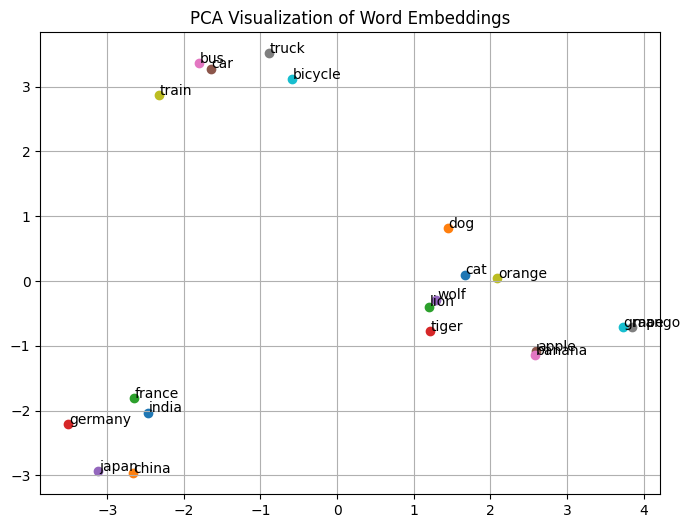

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
for i, word in enumerate(words):
    x, y = pca_result[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)
plt.title("PCA Visualization of Word Embeddings")
plt.grid(True)
plt.show()


In [13]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
tsne_result = tsne.fit_transform(vectors)


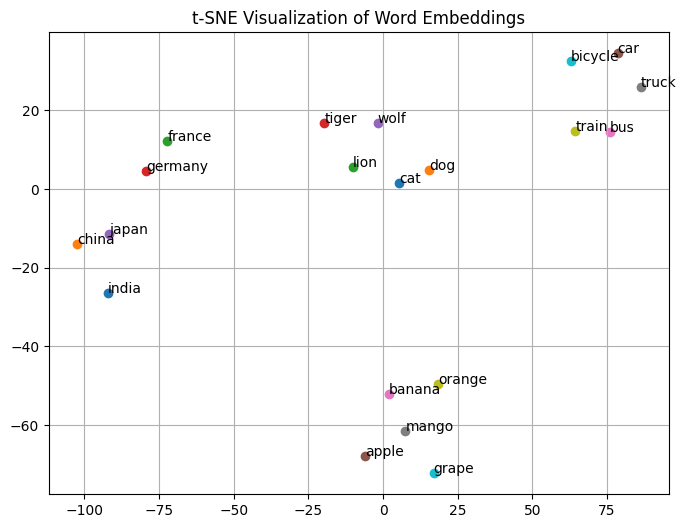

In [15]:
plt.figure(figsize=(8,6))
for i, word in enumerate(words):
    x, y = tsne_result[i]
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, word)

plt.title("t-SNE Visualization of Word Embeddings")
plt.grid(True)
plt.show()
